# DeFiPy: Python SDK for DeFi Analytics
## Chapter 5: Modeling Liquidity Pools

### Listing 5.1 Simulating a Uniswap V2 Liquidity Pool

Exchange TKN1-TKN2 (LP)
Reserves: TKN1 = 958.813629958531, TKN2 = 16808.514097201685
Liquidity: 3837.4604416934544 



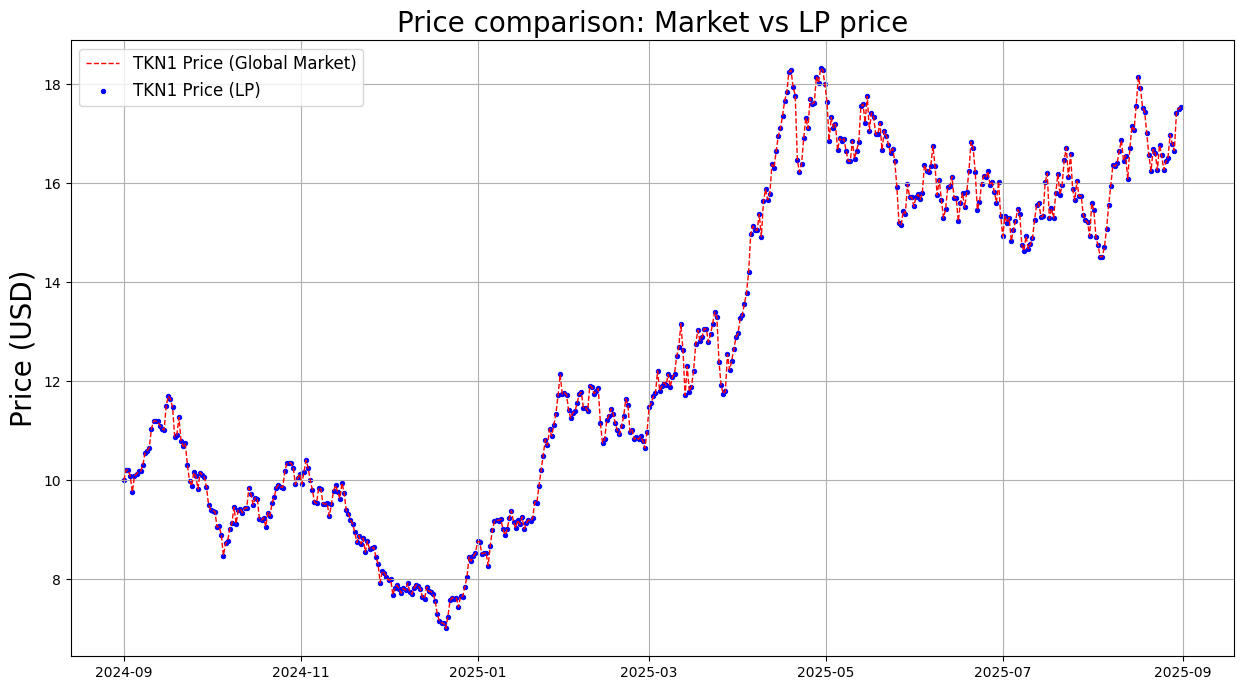

In [7]:
from defipy import *
import numpy as np
import datetime
import matplotlib.pyplot as plt

# Instantiation Parameters
n_steps = 500     # Number of steps 
start_price = 10 # Initial price SYS/USD
mu = 0.1; sigma = 0.5
n_paths = 1      # Number of simulationed paths
seconds_year = 31536000

# Brownian Model 
bm = BrownianModel(start_price)
p_arr = bm.gen_gbms(mu, sigma, n_steps-1, n_paths).flatten()

dt = datetime.timedelta(seconds=seconds_year/n_steps)
dates = [datetime.datetime.strptime("2024-09-01", '%Y-%m-%d') + k*dt for k in range(n_steps)]

# Set up the Uniswap V2 pool
tkn1 = ERC20('TKN1', "0x111")
tkn2 = ERC20('TKN2', "0x09")
exchg_data = UniswapExchangeData(tkn0 = tkn1, tkn1 = tkn2, symbol="LP", address="0x011")

factory = UniswapFactory("pool factory", "0x2")
lp = factory.deploy(exchg_data)
Join().apply(lp, "user", 1000, 10000)

# Run Simulation
arb = CorrectReserves(lp, x0 = p_arr[0])
TKN_amt = TokenDeltaModel(100)
pTKN1_TKN2_arr = []; 

for k in range(n_steps):

    # *****************************
    # ***** Random Swapping ******
    # *****************************
    Swap().apply(lp, tkn1, "user", TKN_amt.delta())
    Swap().apply(lp, tkn2, "user", p_arr[k]*TKN_amt.delta())
    
    # *****************************
    # ***** Rebalance ******
    # *****************************
    arb.apply(p_arr[k])

    # *****************************
    # ******* Data Capture ********
    # *****************************
    pTKN1_TKN2_arr.append(LPQuote().get_price(lp, tkn1))

lp.summary()

# Visualize the pool's price over time
fig, (TKN_ax) = plt.subplots(nrows=1, sharex=False, sharey=False, figsize=(15, 8))

TKN_ax.plot(dates, p_arr, color = 'r',linestyle = 'dashed', linewidth=1, label=f'TKN1 Price (Global Market)')
TKN_ax.scatter(dates, pTKN1_TKN2_arr, s=10, marker='o', color = 'b',linestyle = '-', linewidth=0.7, label=f'TKN1 Price (LP)')

TKN_ax.set_title('Price comparison: Market vs LP price', fontsize=20)
TKN_ax.set_ylabel('Price (USD)', size=20)
TKN_ax.legend(fontsize=12)
TKN_ax.grid()

### Listing 5.2: Simulating a Liquidity Pool with a Four-State FSM Token

In [8]:
from defipy import *
import numpy as np
import datetime
from scipy.stats import beta

# Instantiation Parameters
n_steps = 500     # Number of steps 
start_price = 10 # Initial price SYS/USD
mu = 0.1; sigma = 0.5
n_paths = 1      # Number of simulationed paths
seconds_year = 31536000

# Brownian Model 
bm = BrownianModel(start_price)
p_arr = bm.gen_gbms(mu, sigma, n_steps-1, n_paths).flatten()

dt = datetime.timedelta(seconds=seconds_year/n_steps)
dates = [datetime.datetime.strptime("2024-09-01", '%Y-%m-%d') + k*dt for k in range(n_steps)]

user_nm = 'user0'
finite_tkn_amt = 1000
market_tkn_amt = p_arr[0]*finite_tkn_amt

ftkn_nm = 'FTKN'
mtkn_nm = 'MTKN'

lp_state = TokenSupplyState(stochastic = True)
TKN_amt = TokenDeltaModel(100)

finite_tkn = ERC20(ftkn_nm, "0x111")
market_tkn = ERC20(mtkn_nm, "0x09")
exchg_data = UniswapExchangeData(tkn0 = finite_tkn, tkn1 = market_tkn, symbol="LP", address="0x011")

factory = UniswapFactory("pool factory", "0x2")
lp = factory.deploy(exchg_data)
Join().apply(lp, user_nm, finite_tkn_amt, market_tkn_amt)

lp.summary()

arb = CorrectReserves(lp, x0 = p_arr[0])
mint_finite_tkn_deposit = TKN_amt.delta()
lp_state.next_state(mint_finite_tkn_deposit) 

pFTKN_MTKN_arr = []; 

for k in range(n_steps):

    # Token Supply 
    mint_finite_tkn_deposit = TKN_amt.delta()
    lp_state.next_state(mint_finite_tkn_deposit) 
    lp_diff_amt = lp_state.get_current_state('dLP')  

    if(lp_diff_amt > 0):
        AddLiquidity().apply(lp, finite_tkn, user_nm, lp_diff_amt)        
    elif(lp_diff_amt < 0):
        RemoveLiquidity().apply(lp, finite_tkn, user_nm, abs(lp_diff_amt))  
    
    # Random Swapping 
    Swap().apply(lp, finite_tkn, user_nm, TKN_amt.delta())
    Swap().apply(lp, market_tkn, user_nm, p_arr[k]*TKN_amt.delta())
    
    # Rebalance 
    arb.apply(p_arr[k])

    # Data Capture 
    pFTKN_MTKN_arr.append(LPQuote().get_price(lp, finite_tkn))

lp.summary()

Exchange FTKN-MTKN (LP)
Reserves: FTKN = 1000.0, MTKN = 10000.0
Liquidity: 3162.2776601683795 

Exchange FTKN-MTKN (LP)
Reserves: FTKN = 5437.938988690382, MTKN = 52207.520975899526
Liquidity: 16550.216478286864 

